# Truncated Analysis


In [68]:
from pathlib import Path
import os
import re

import numpy as np
import pandas as pd

from ANALYSIS_HW_HD_utils import *
from ANALYSIS_plots_utils import *
from ANALYSIS_create_npy_file import create_npy_file, create_npy_file_truncated


Call the directory where the traces are saved and the result directory 

In [69]:
truncated_registers = ["r2", "r3", "r4", "r5", "r6"]
truncated_trace_dir = "output_decapsulation_truncated_TRIM"
result_dir_truncated = "Results_decapsulation_truncated"
no_instructions = 100 
selected_fault_index = 0
reset_folder(result_dir_truncated)

os.makedirs(result_dir_truncated, exist_ok=True)

create_npy_file_truncated(f"{result_dir_truncated}/HW_SUBTRACE", truncated_trace_dir, "HW", truncated_registers, selected_fault_index)
create_npy_file_truncated(f"{result_dir_truncated}/HD_SUBTRACE", truncated_trace_dir, "HD", truncated_registers, selected_fault_index)

data_HW_by_register = {}
# create one .npy file per register and per xs_id, and load them into a dictionary
for reg in truncated_registers:
    create_npy_file_truncated(
        f"{result_dir_truncated}/HW_SUBTRACE_{reg}",
        truncated_trace_dir,
        "HW",
        [reg],
        selected_fault_index,
    )

    data_HW_by_register[reg] = {}

    for file in sorted(Path(result_dir_truncated).glob(f"HW_SUBTRACE_{reg}_xs*.npy")):
        match = re.search(r"xs(\d+)", file.stem)
        xs = int(match.group(1))
        data_HW_by_register[reg][xs] = np.load(file)

create_npy_file_truncated(
    f"{result_dir_truncated}/HW_SUBTRACE_r0",
    truncated_trace_dir,
    "HW",
    ["r0"],
    selected_fault_index,
)
create_npy_file_truncated(
    f"{result_dir_truncated}/HD_SUBTRACE_r0",
    truncated_trace_dir,
    "HD",
    ["r0"],
    selected_fault_index,
)



Creating simulation traces model.... HW
Found 640 truncated trace files for fault_index=0
Trace 0 has been converted
Trace row 0 for xs=0, fault=0 -> trace_0_0_0.csv
Trace row 0 for xs=1, fault=0 -> trace_0_1_0.csv
Trace row 0 for xs=2, fault=0 -> trace_0_2_0.csv
Trace row 0 for xs=3, fault=0 -> trace_0_3_0.csv
Trace row 0 for xs=4, fault=0 -> trace_0_4_0.csv
Trace row 0 for xs=5, fault=0 -> trace_0_5_0.csv
Trace row 0 for xs=6, fault=0 -> trace_0_6_0.csv
Trace row 0 for xs=7, fault=0 -> trace_0_7_0.csv
Trace row 1 for xs=0, fault=0 -> trace_1_0_0.csv
Trace row 1 for xs=1, fault=0 -> trace_1_1_0.csv
Trace row 1 for xs=2, fault=0 -> trace_1_2_0.csv
Trace row 1 for xs=3, fault=0 -> trace_1_3_0.csv
Trace row 1 for xs=4, fault=0 -> trace_1_4_0.csv
Trace row 1 for xs=5, fault=0 -> trace_1_5_0.csv
Trace row 1 for xs=6, fault=0 -> trace_1_6_0.csv
Trace row 1 for xs=7, fault=0 -> trace_1_7_0.csv
Trace row 2 for xs=0, fault=0 -> trace_2_0_0.csv
Trace row 2 for xs=1, fault=0 -> trace_2_1_0.csv
T

In [70]:
data_HW_truncated = {}
print("Information HW truncated")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HW_SUBTRACE_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HW_truncated[xs_id] = np.load(file)
    information(data_HW_truncated[xs_id])

data_HD_truncated = {}

print("\nInformation HD truncated")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HD_SUBTRACE_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HD_truncated[xs_id] = np.load(file)
    information(data_HD_truncated[xs_id])

data_HW_r0 = {}
print("\nInformation HW r0")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HW_SUBTRACE_r0_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HW_r0[xs_id] = np.load(file)
    information(data_HW_r0[xs_id])

data_HD_r0 = {}
print("\nInformation HD r0")
print("------------------------")
for file in sorted(Path(result_dir_truncated).glob("HD_SUBTRACE_r0_xs*.npy")):
    match = re.search(r"xs(\d+)", file.stem)
    xs_id = int(match.group(1))
    data_HD_r0[xs_id] = np.load(file)
    information(data_HD_r0[xs_id])



Information HW truncated
------------------------
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[44. 44. 44. ... 78. 78. 78.]
 [44. 44. 44. ... 82. 82. 82.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[63. 63. 63. ... 78. 78. 78.]
 [64. 64. 64. ... 82. 82. 82.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[63. 63. 63. ... 78. 78. 78.]
 [64. 64. 64. ... 82. 82. 82.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[63. 63. 63. ... 78. 78. 78.]
 [64. 64. 64. ... 82. 82. 82.]]
If there are any NaN values: False
The shape of the data is: (80, 3616)
The type of the data is: float64
The first 2 traces are: [[63. 63. 63. ... 78. 78. 78.]
 [64. 64. 64. ... 82. 82. 82.]]
If there are any NaN valu

Load one B for each trace and all B for all the ciphertext that have been generated

In [71]:
def load_B(run_index, B_folder, prefix="B", fault_index=None):
    if fault_index is None:
        path = Path(B_folder) / f"{prefix}_{run_index}.csv"
    else:
        path = Path(B_folder) / f"{prefix}_{run_index}_{fault_index}.csv"

    if not path.exists():
        raise FileNotFoundError(f"Missing B file: {path}")

    df = pd.read_csv(path)
    value_cols = [col for col in df.columns if col != "row"]
    return df[value_cols].to_numpy(dtype=np.float64)


def load_all_B(B_folder, prefix="B", fault_index=None):
    if fault_index is None:
        pattern = re.compile(rf"{re.escape(prefix)}_(\d+)\.csv$")
    else:
        pattern = re.compile(rf"{re.escape(prefix)}_(\d+)_{fault_index}\.csv$")

    files = []
    for path in Path(B_folder).glob(f"{prefix}_*.csv"):
        match = pattern.fullmatch(path.name)
        if match is not None:
            files.append((int(match.group(1)), path))

    files.sort(key=lambda item: item[0])

    if not files:
        suffix = "" if fault_index is None else f" for fault_index={fault_index}"
        raise FileNotFoundError(f"No {prefix}_*.csv files found in {B_folder}{suffix}")

    runs = [run_index for run_index, _ in files]
    B_all = np.array([
        load_B(run_index, B_folder, prefix=prefix, fault_index=fault_index)
        for run_index in runs
    ])
    return B_all, runs



Data for modified B
B_all shape: (80, 8, 640)
B_from_registers shape: (80, 8, 640)
B_packed_from_registers shape: (80, 8, 320)

Data for valid B
B_valid shape: (80, 8, 640)
B_valid_from_registers shape: (80, 8, 640)
B_valid_packed_from_registers shape: (80, 8, 320)



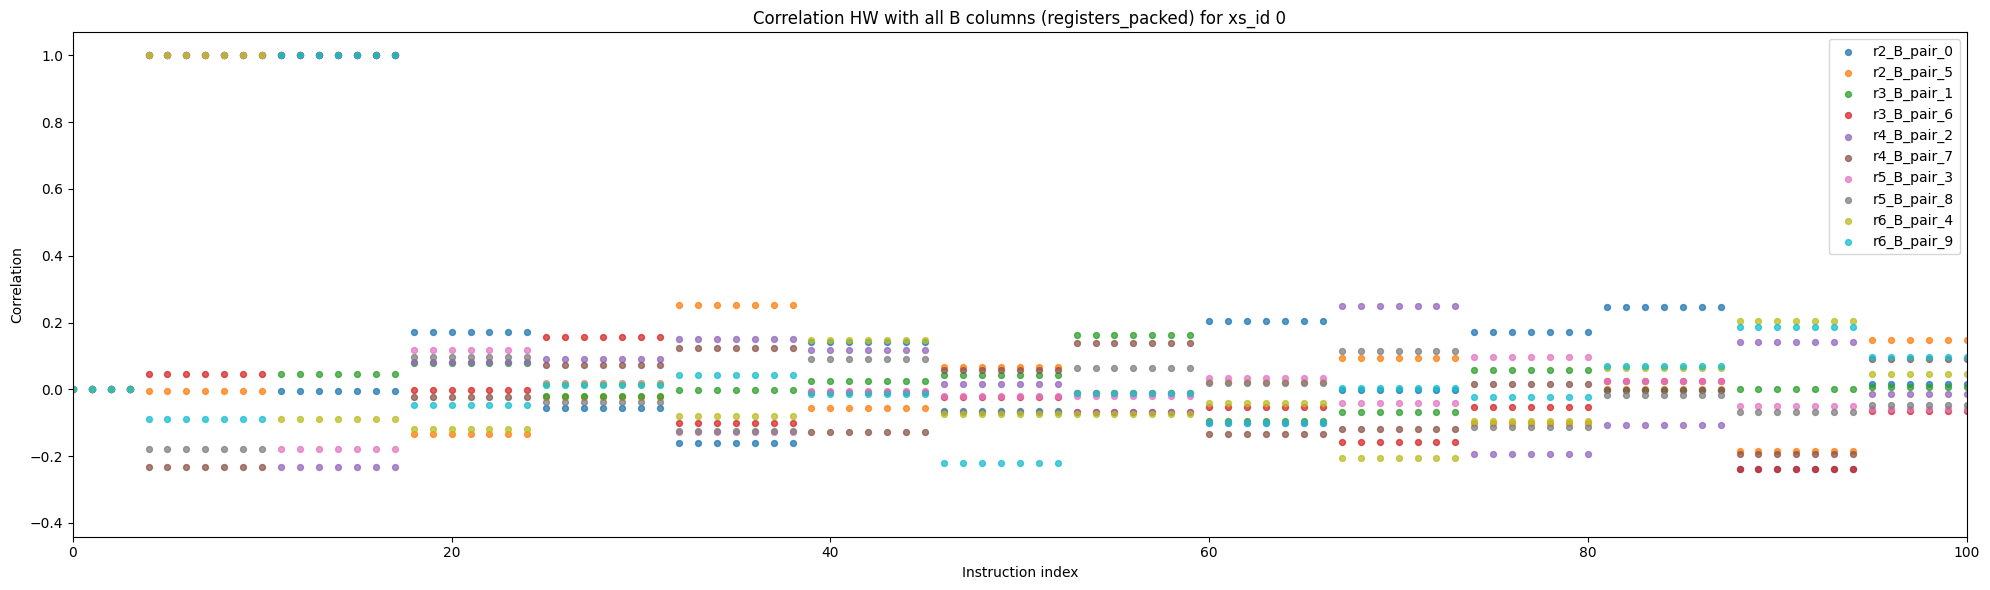

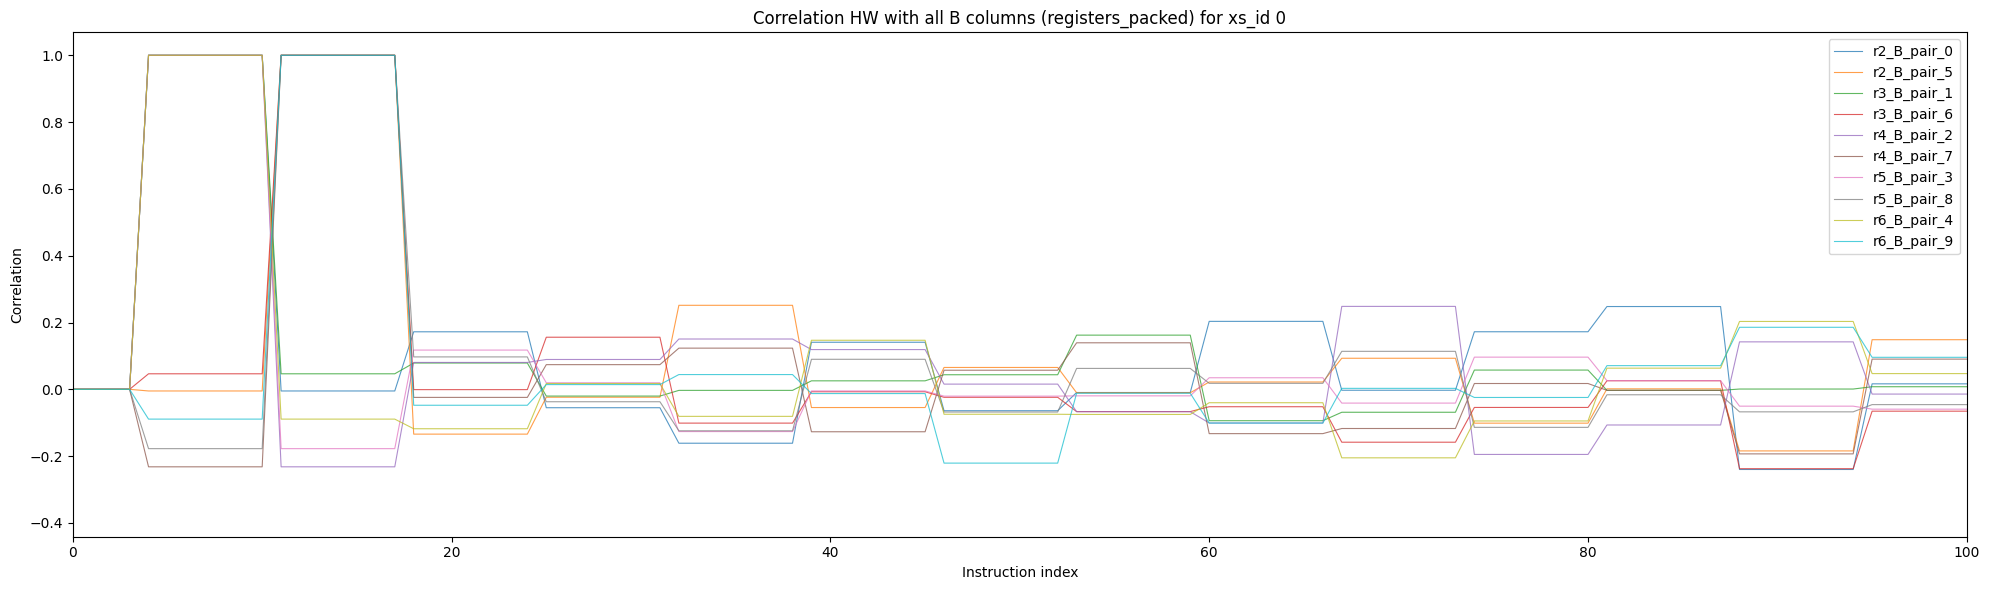

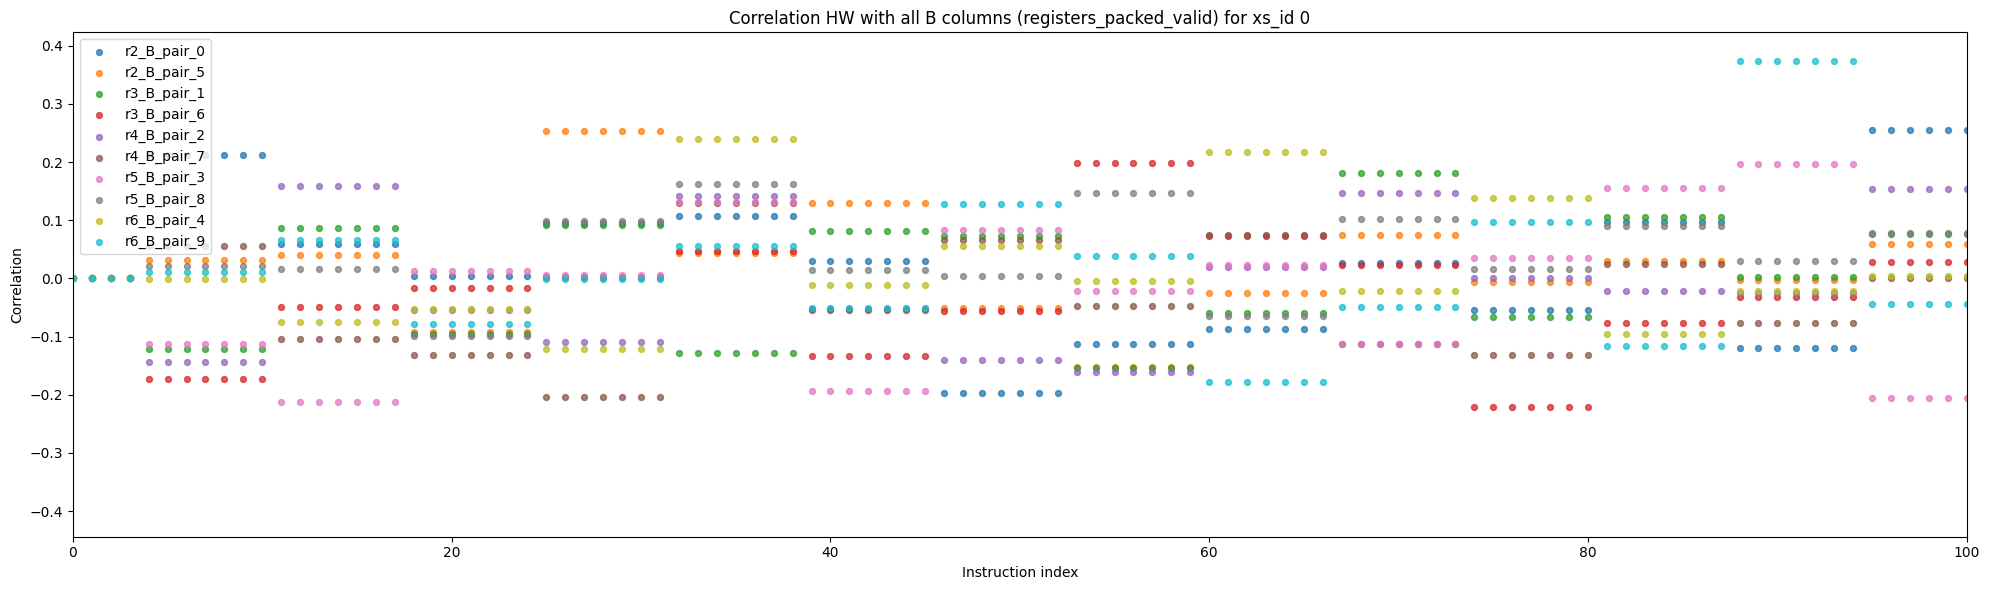

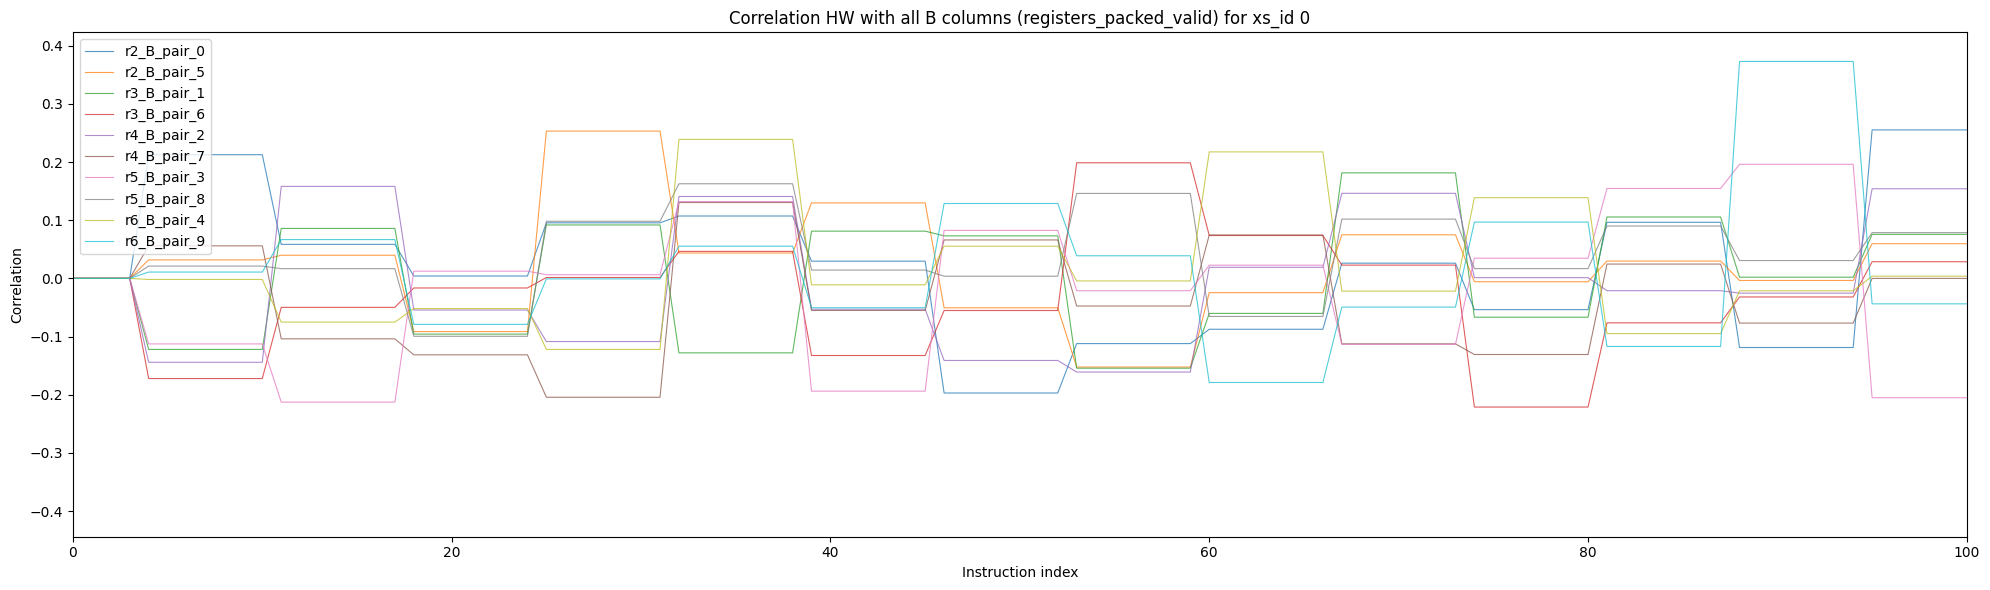

In [72]:
B_folder = Path("output_decapsulation_truncated/B")

B_all, B_runs = load_all_B(B_folder, prefix="B", fault_index=selected_fault_index)
B_valid, B_valid_runs = load_all_B(B_folder, prefix="B_valid")

B_from_registers, B_register_runs = load_all_B(B_folder, prefix="B_from_registers", fault_index=selected_fault_index)
B_valid_from_registers, B_valid_register_runs = load_all_B(B_folder, prefix="B_valid_from_registers")

B_packed_from_registers, B_packed_runs = load_all_B(B_folder, prefix="B_from_registers_packed", fault_index=selected_fault_index)
B_valid_packed_from_registers, B_valid_packed_runs = load_all_B(B_folder, prefix="B_valid_from_registers_packed")

print("\nData for modified B")
print("B_all shape:", B_all.shape)
print("B_from_registers shape:", B_from_registers.shape)
print("B_packed_from_registers shape:", B_packed_from_registers.shape)
print("\nData for valid B")
print("B_valid shape:", B_valid.shape)
print("B_valid_from_registers shape:", B_valid_from_registers.shape)
print("B_valid_packed_from_registers shape:", B_valid_packed_from_registers.shape)

print()

xs_id = 0
traces_hw = data_HW_truncated[xs_id]
traces_hd = data_HD_truncated[xs_id]

B_row = xs_id
no_B_cols = 10 

B_base = {
    # "ciphertext": B_all,
    # "registers": B_from_registers,
    "registers_packed": B_packed_from_registers,
}

B_valid_base = {
    # "ciphertext_valid": B_valid,
    # "registers_valid": B_valid_from_registers,
    "registers_packed_valid": B_valid_packed_from_registers,
}

for B_name, B_values in B_base.items():
    corr_hw_array = {}

    for B_col in range(no_B_cols):
        register_values = B_values[:, B_row, B_col]
        target_hw_values = hw_u32(register_values.astype(np.uint32))

        if B_name == "registers_packed":
            # register index is determined by the column index modulo the number of truncated registers -> look in Ghidra 
            reg_index = B_col % len(truncated_registers)
            reg = truncated_registers[reg_index]

            traces_hw_for_corr = data_HW_by_register[reg][xs_id]
            label = f"{reg}_B_pair_{B_col}"
        else:
            traces_hw_for_corr = traces_hw
            label = f"B_col_{B_col}"
   

        corr_hw_array[label] = compute_correlation(traces_hw_for_corr,target_hw_values)

    plot_correlation(corr_hw_array,f"Correlation HW with all B columns ({B_name}) for xs_id {xs_id}", os.path.join(result_dir_truncated,f"correlation_HW_all_B_cols_{B_name}_xs{xs_id}.png"),no_instructions=no_instructions, style="points", marker_size=18)
    plot_correlation(corr_hw_array,f"Correlation HW with all B columns ({B_name}) for xs_id {xs_id}", os.path.join(result_dir_truncated,f"correlation_HW_all_B_cols_{B_name}_xs{xs_id}_line.png"),no_instructions=no_instructions, style="line", marker_size=18)

for B_name, B_values in B_valid_base.items():
    corr_hw_array = {}

    for B_col in range(no_B_cols):
        register_values = B_values[:, B_row, B_col]
        target_hw_values = hw_u32(register_values.astype(np.uint32))

        if B_name == "registers_packed_valid":
            # register index is determined by the column index modulo the number of truncated registers -> look in Ghidra 
            reg_index = B_col % len(truncated_registers)
            reg = truncated_registers[reg_index]

            traces_hw_for_corr = data_HW_by_register[reg][xs_id]
            label = f"{reg}_B_pair_{B_col}"
        else:
            traces_hw_for_corr = traces_hw
            label = f"B_col_{B_col}"

        corr_hw_array[label] = compute_correlation(traces_hw_for_corr,target_hw_values)

    plot_correlation(corr_hw_array,f"Correlation HW with all B columns ({B_name}) for xs_id {xs_id}", os.path.join(result_dir_truncated,f"correlation_HW_all_B_cols_{B_name}_xs{xs_id}.png"),no_instructions=no_instructions, style="points", marker_size=18)
    plot_correlation(corr_hw_array,f"Correlation HW with all B columns ({B_name}) for xs_id {xs_id}", os.path.join(result_dir_truncated,f"correlation_HW_all_B_cols_{B_name}_xs{xs_id}_line.png"),no_instructions=no_instructions, style="line", marker_size=18)


In [73]:
S_df = pd.read_csv("output_decapsulation_truncated/S/S.csv")
S_real = S_df[[f"S_col_{j}" for j in range(8)]].to_numpy(dtype=np.int16)


Correlation between B[i] * S[i] +  B[i+1] * S[i+1]

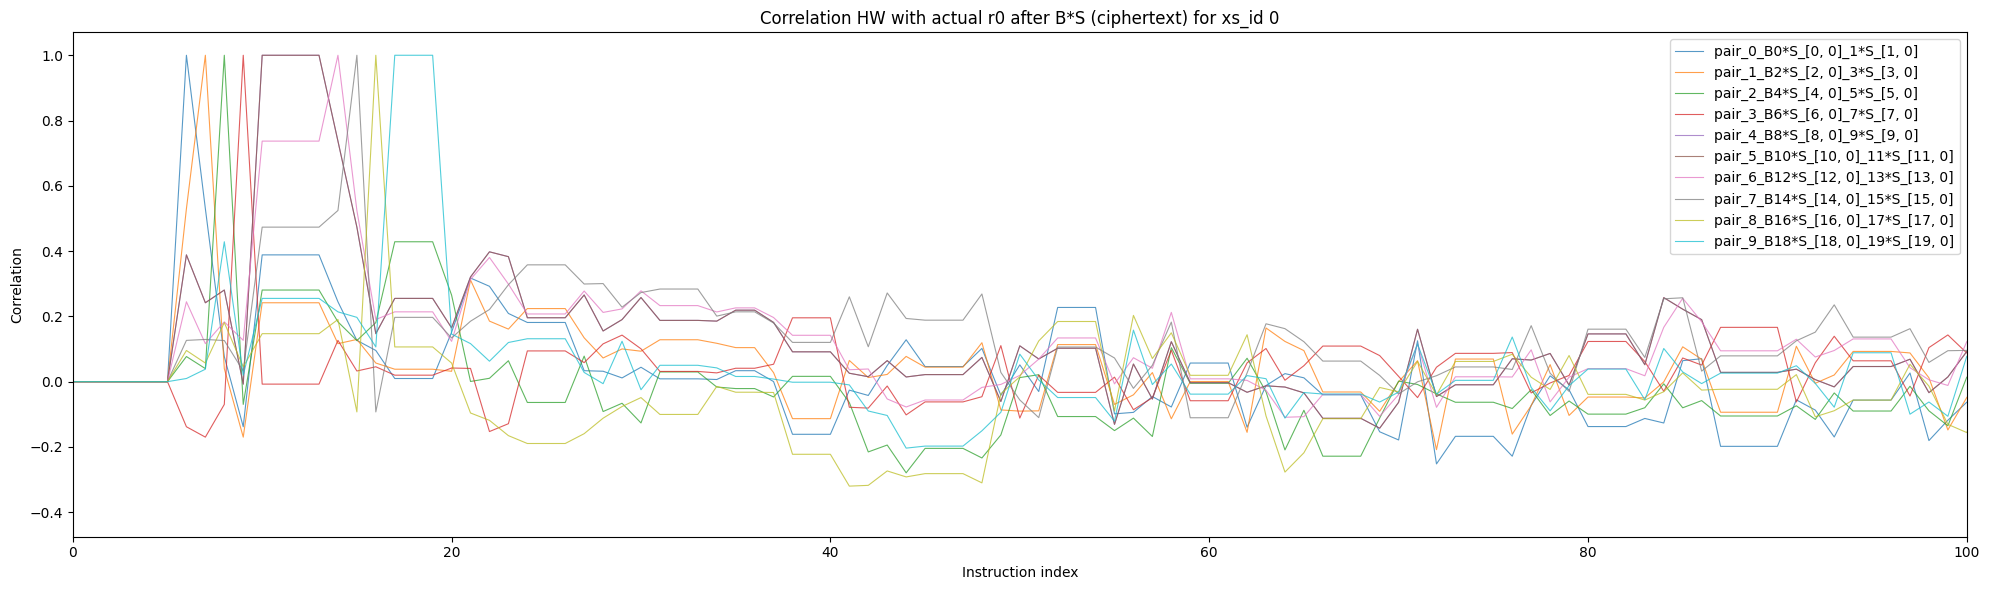

In [74]:
xs_id = 0
B_row = xs_id
no_pairs = 10

traces_hw_r0 = data_HW_r0[xs_id]
traces_hd_r0 = data_HD_r0[xs_id]

B_times_S_base = {
    "ciphertext": B_all,
    # "registers": B_from_registers,
    #"registers_packed": B_packed_from_registers,
}

for B_name, B_values in B_times_S_base.items():
    corr_hw_product_array = {}
    corr_hw_accumulator_array = {}

    r0_old = np.zeros(B_values.shape[0], dtype=np.int32)

    for pair_idx in range(no_pairs):
        B_col = 2 * pair_idx
        B_col_next = B_col + 1

        if B_col_next >= B_values.shape[2]:
            break

        S0 = int(S_real[B_col, xs_id])
        S1 = int(S_real[B_col_next, xs_id])

        pair_product = (
            B_values[:, B_row, B_col].astype(np.int32) * S0
            + B_values[:, B_row, B_col_next].astype(np.int32) * S1
        )

        r0_new = r0_old + pair_product

        target_hw_product = hw_u32(pair_product & 0xffffffff)
        target_hw_accumulator = hw_u32(r0_new & 0xffffffff)
        target_hd_accumulator = hw_u32((r0_old ^ r0_new) & 0xffffffff)

        label = f"pair_{pair_idx}_B{B_col}*S_[{B_col}, {xs_id}]_{B_col_next}*S_[{B_col_next}, {xs_id}]"

        corr_hw_product_array[label] = compute_correlation(traces_hw_r0,target_hw_product)
        corr_hw_accumulator_array[label] = compute_correlation(traces_hw_r0,target_hw_accumulator)

        r0_old = r0_new

    plot_correlation(corr_hw_accumulator_array, f"Correlation HW with actual r0 after B*S ({B_name}) for xs_id {xs_id}",os.path.join(result_dir_truncated,f"correlation_HW_actual_BS_accumulator_{B_name}_xs{xs_id}.png",),no_instructions=no_instructions,)




## Guess S by correlation


In [75]:
def print_best_guess(corr_array, label, local_sample_idx, real_instruction_idx):
    best_guess = None
    best_abs_corr = -1
    best_corr = None

    for guess_label, corr in corr_array.items():
        guess = int(guess_label.replace("S_", ""))
        corr = np.asarray(corr, dtype=np.float64)

        target_corr = float(corr[local_sample_idx])
        target_abs = abs(target_corr)

        if target_abs > best_abs_corr:
            best_guess = guess
            best_abs_corr = target_abs
            best_corr = target_corr

    print(f"{label} best guess: {best_guess}")
    print(f"{label} abs correlation at target: {best_abs_corr:.6f}")
    print(f"{label} signed correlation at target: {best_corr:.6f}")
    print(f"{label} real instruction index: {real_instruction_idx}")
    return best_guess

Value that we try to guess 

In [76]:
B_col = 0
B_row = 4
xs_id = 0

S_guesses = range(-10,11)

In [77]:
if B_col % 2 != 0:
    raise ValueError("B_col must be even because smlad uses pairs: [0,1], [2,3], ...")

B_col_next = B_col + 1
pair_idx = B_col // 2

# Create the actual pair 
S_true = int(S_real[B_col, xs_id])
S_true_next = int(S_real[B_col_next, xs_id])

print(f"True pair: S[{B_col},{xs_id}] = {S_true}, S[{B_col_next},{xs_id}] = {S_true_next}")

r0_old = np.zeros(B_all.shape[0], dtype=np.int32)

for prev_pair in range(pair_idx):
    k0 = 2 * prev_pair
    k1 = k0 + 1

    r0_old += (
        B_all[:, B_row, k0].astype(np.int32) * int(S_real[k0, xs_id])
        + B_all[:, B_row, k1].astype(np.int32) * int(S_real[k1, xs_id])
    )

trace_df = pd.read_csv(f"output_decapsulation_truncated_TRIM/trace_0_{xs_id}_{selected_fault_index}.csv")
trace_df["instruction"] = trace_df["instruction"].astype(str).str.strip().str.lower()

smlad_indices = trace_df.index[trace_df["instruction"] == "smlad"].to_numpy()
smlads_per_xs_call = 320 # 640 // 2 
smlad_global_idx = B_row * smlads_per_xs_call + pair_idx
target_smlad_instruction = int(smlad_indices[smlad_global_idx])

print(f"pair_idx = {pair_idx}")
print(f"smlad_global_idx = {smlad_global_idx}")
print(f"target_smlad_instruction = {target_smlad_instruction}")

instructions_before = 0
instructions_after = 10

hw_target_real = target_smlad_instruction + 1
hd_target_real = target_smlad_instruction

hw_start = max(0, hw_target_real - instructions_before)
traces_hw_r0 = data_HW_r0[xs_id]
traces_hd_r0 = data_HD_r0[xs_id]

hw_end = min(traces_hw_r0.shape[1], hw_target_real + instructions_after + 1)

hd_start = max(0, hd_target_real - instructions_before)
hd_end = min(traces_hd_r0.shape[1], hd_target_real + instructions_after + 1)

traces_hw_guess = traces_hw_r0[:, hw_start:hw_end]
traces_hd_guess = traces_hd_r0[:, hd_start:hd_end]

hw_target_local = hw_target_real - hw_start
hd_target_local = hd_target_real - hd_start

pair_scores = []

for S_guess_0 in S_guesses:
    for S_guess_1 in S_guesses:
        pair_product = (
            B_all[:, B_row, B_col].astype(np.int32) * int(S_guess_0)
            + B_all[:, B_row, B_col_next].astype(np.int32) * int(S_guess_1)
        )

        r0_new = r0_old + pair_product

        target_hw = hw_u32(r0_new & 0xffffffff)
        target_hd = hw_u32((r0_old ^ r0_new) & 0xffffffff)

        corr_hw = compute_correlation(traces_hw_guess, target_hw)
        corr_hd = compute_correlation(traces_hd_guess, target_hd)

        hw_corr = corr_hw[hw_target_local]
        hd_corr = corr_hd[hd_target_local]

        pair_scores.append({
            "S0": S_guess_0,
            "S1": S_guess_1,
            "HW_score": abs(hw_corr),
            "HD_score": abs(hd_corr),
            "HW_corr": hw_corr,
            "HD_corr": hd_corr,
        })

pair_scores_hw = sorted(pair_scores, key=lambda x: x["HW_score"], reverse=True)
pair_scores_hd = sorted(pair_scores, key=lambda x: x["HD_score"], reverse=True)

best_hw = pair_scores_hw[0]
# best_hd = pair_scores_hd[0]

print(f"Best pair HW is: S0 = {best_hw['S0']}, S1 = {best_hw['S1']} with abs correlation {best_hw['HW_score']:.6f}")
# print(f"Best pair HD is: S0 = {best_hd['S0']}, S1 = {best_hd['S1']}")


True pair: S[0,0] = 3, S[1,0] = -3
pair_idx = 0
smlad_global_idx = 1280
target_smlad_instruction = 1813
Best pair HW is: S0 = 3, S1 = -3 with abs correlation 1.000000


## Packed S-Pair Rank Matrix

For each xs() call, compute the rank of the true of the pair that was obtained from the correlation


In [78]:
def find_true_pair_rank(B, title):    
    S_guesses = range(-10, 11)

    S_pair_rank_hw = np.full((8, B.shape[2] // 2), np.nan)
    S_pair_true_hw_score = np.full((8, B.shape[2] // 2), np.nan)
    S_pair_best_hw_score = np.full((8, B.shape[2] // 2), np.nan)
    S_pair_best_guess = np.empty((8, B.shape[2] // 2), dtype=object)
    S_pair_true_value = np.empty((8, B.shape[2] // 2), dtype=object)

    rank_details = []
    smlads_per_xs_call = 320  # 640 // 2
    instructions_before = 0
    instructions_after = 10


    def rank_true_packed_pair(xs_id, pair_idx, b_row=None):
        if b_row is None:
            b_row = xs_id

        b_col = 2 * pair_idx
        b_col_next = b_col + 1

        S0_true = int(S_real[b_col, xs_id])
        S1_true = int(S_real[b_col_next, xs_id])

        r0_old = np.zeros(B.shape[0], dtype=np.int32)
        for prev_pair in range(pair_idx):
            k0 = 2 * prev_pair
            k1 = k0 + 1
            r0_old += (
                B[:, b_row, k0].astype(np.int32) * int(S_real[k0, xs_id])
                + B[:, b_row, k1].astype(np.int32) * int(S_real[k1, xs_id])
            )

        trace_df = pd.read_csv(f"output_decapsulation_truncated_TRIM/trace_0_{xs_id}_{selected_fault_index}.csv")
        trace_df["instruction"] = trace_df["instruction"].astype(str).str.strip().str.lower()
        smlad_indices = trace_df.index[trace_df["instruction"] == "smlad"].to_numpy()

        smlad_global_idx = b_row * smlads_per_xs_call + pair_idx
        target_smlad_instruction = int(smlad_indices[smlad_global_idx])

        hw_target_real = target_smlad_instruction + 1
        traces_hw_r0 = data_HW_r0[xs_id]

        hw_start = max(0, hw_target_real - instructions_before)
        hw_end = min(traces_hw_r0.shape[1], hw_target_real + instructions_after + 1)
        traces_hw_guess = traces_hw_r0[:, hw_start:hw_end]
        hw_target_local = hw_target_real - hw_start

        pair_scores = []
        for S_guess_0 in S_guesses:
            for S_guess_1 in S_guesses:
                pair_product = (
                    B[:, b_row, b_col].astype(np.int32) * int(S_guess_0)
                    + B[:, b_row, b_col_next].astype(np.int32) * int(S_guess_1)
                )
                r0_new = r0_old + pair_product
                target_hw = hw_u32(r0_new & 0xffffffff)
                corr_hw = compute_correlation(traces_hw_guess, target_hw)
                hw_corr = corr_hw[hw_target_local]

                pair_scores.append({
                    "S0": int(S_guess_0),
                    "S1": int(S_guess_1),
                    "HW_score": abs(hw_corr),
                    "HW_corr": hw_corr,
                })

        pair_scores_hw = sorted(pair_scores, key=lambda row: row["HW_score"], reverse=True)

        true_rank = None
        true_score = None
        true_corr = None
        for rank, row in enumerate(pair_scores_hw, start=1):
            if (row["S0"], row["S1"]) == (S0_true, S1_true):
                true_rank = rank
                true_score = row["HW_score"]
                true_corr = row["HW_corr"]
                break

        best = pair_scores_hw[0]
        return {
            "xs_id": xs_id,
            "b_row": b_row,
            "pair_idx": pair_idx,
            "b_col": b_col,
            "b_col_next": b_col_next,
            "S0_true": S0_true,
            "S1_true": S1_true,
            "S0_best_hw": best["S0"],
            "S1_best_hw": best["S1"],
            "HW_rank_true_pair": true_rank,
            "HW_true_score": true_score,
            "HW_true_corr": true_corr,
            "HW_best_score": best["HW_score"],
            "HW_best_corr": best["HW_corr"],
        }

    for xs_id in range(8):
        print(f"Computing packed S-pair ranks for xs_id={xs_id}")
        for pair_idx in range(B.shape[2] // 2):
            result = rank_true_packed_pair(xs_id, pair_idx, b_row=xs_id)
            rank_details.append(result)

            S_pair_rank_hw[xs_id, pair_idx] = result["HW_rank_true_pair"]
            S_pair_true_hw_score[xs_id, pair_idx] = result["HW_true_score"]
            S_pair_best_hw_score[xs_id, pair_idx] = result["HW_best_score"]
            S_pair_best_guess[xs_id, pair_idx] = f"({result['S0_best_hw']},{result['S1_best_hw']})"
            S_pair_true_value[xs_id, pair_idx] = f"({result['S0_true']},{result['S1_true']})"

            if pair_idx % 40 == 0:
                print(
                    f"  pair_idx={pair_idx:3}: true=({result['S0_true']},{result['S1_true']}), "
                    f"best=({result['S0_best_hw']},{result['S1_best_hw']}), "
                    f"rank={result['HW_rank_true_pair']}"
                )

    pair_columns = [f"S_pair_{i}" for i in range(B.shape[2] // 2)]

    rank_df = pd.DataFrame(S_pair_rank_hw.astype(int), columns=pair_columns)
    rank_df.index.name = "xs_id"
    rank_path = os.path.join(result_dir_truncated, f"S_pair_rank_HW_packed_{title}.csv")
    rank_df.to_csv(rank_path)

    # true_pair_df = pd.DataFrame(S_pair_true_value, columns=pair_columns)
    # true_pair_df.index.name = "xs_id"
    #true_pair_path = os.path.join(result_dir_truncated, f"S_pair_true_values_packed_{title}.csv")
    # true_pair_df.to_csv(true_pair_path)

    # best_pair_df = pd.DataFrame(S_pair_best_guess, columns=pair_columns)
    # best_pair_df.index.name = "xs_id"
    # best_pair_path = os.path.join(result_dir_truncated, f"S_pair_best_guess_HW_packed_{title}.csv")
    # best_pair_df.to_csv(best_pair_path)

    # score_df = pd.DataFrame(S_pair_true_hw_score, columns=pair_columns)
    # score_df.index.name = "xs_id"
    # score_path = os.path.join(result_dir_truncated, f"S_pair_true_score_HW_packed_{title}.csv")
    # score_df.to_csv(score_path)

    # details_df = pd.DataFrame(rank_details)
    # details_path = os.path.join(result_dir_truncated, f"S_pair_rank_HW_details_{title}.csv")
    # details_df.to_csv(details_path, index=False)

    print(f"Saved packed true-pair rank matrix to {rank_path}")
    # print(f"Saved packed true-pair values to {true_pair_path}")
    # print(f"Saved packed best guesses to {best_pair_path}")
    # print(f"Saved packed true-pair scores to {score_path}")
    # print(f"Saved detailed rank table to {details_path}")

    print("Rank matrix summary:")
    print(rank_df.stack().describe())

find_true_pair_rank(B_all, "B_all")
find_true_pair_rank(B_valid, "B_valid")



Computing packed S-pair ranks for xs_id=0
  pair_idx=  0: true=(3,-3), best=(3,-3), rank=1
  pair_idx= 40: true=(1,2), best=(1,2), rank=1
  pair_idx= 80: true=(4,5), best=(4,5), rank=1
  pair_idx=120: true=(-3,-6), best=(-3,-6), rank=1
  pair_idx=160: true=(0,-2), best=(0,-2), rank=1
  pair_idx=200: true=(0,1), best=(0,1), rank=1
  pair_idx=240: true=(-3,0), best=(-3,0), rank=1
  pair_idx=280: true=(1,1), best=(1,1), rank=1
Computing packed S-pair ranks for xs_id=1
  pair_idx=  0: true=(-3,1), best=(-3,1), rank=1
  pair_idx= 40: true=(2,1), best=(2,1), rank=1
  pair_idx= 80: true=(2,-3), best=(2,-3), rank=1
  pair_idx=120: true=(-5,-2), best=(-5,-2), rank=1
  pair_idx=160: true=(0,-1), best=(0,-1), rank=1
  pair_idx=200: true=(4,3), best=(4,3), rank=1
  pair_idx=240: true=(-5,0), best=(-5,0), rank=1
  pair_idx=280: true=(1,-3), best=(1,-3), rank=1
Computing packed S-pair ranks for xs_id=2
  pair_idx=  0: true=(0,1), best=(0,1), rank=1
  pair_idx= 40: true=(0,5), best=(0,5), rank=1
  pa

/var/folders/9_/_gg94zdd64qdbw0dmll8z2y40000gn/T/ipykernel_63902/3896225257.py:120: RuntimeWarning: invalid value encountered in cast
  rank_df = pd.DataFrame(S_pair_rank_hw.astype(int), columns=pair_columns)


Saved packed true-pair rank matrix to Results_decapsulation_truncated/S_pair_rank_HW_packed_B_all.csv
Rank matrix summary:
count    2560.000000
mean        1.001953
std         0.065534
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         3.000000
dtype: float64
Computing packed S-pair ranks for xs_id=0
  pair_idx=  0: true=(3,-3), best=(2,3), rank=179
  pair_idx= 40: true=(1,2), best=(7,-3), rank=161
  pair_idx= 80: true=(4,5), best=(-6,-5), rank=178
  pair_idx=120: true=(-3,-6), best=(-2,-10), rank=65
  pair_idx=160: true=(0,-2), best=(-4,-8), rank=165
  pair_idx=200: true=(0,1), best=(-10,-7), rank=424
  pair_idx=240: true=(-3,0), best=(-7,-2), rank=397
  pair_idx=280: true=(1,1), best=(-1,3), rank=323
Computing packed S-pair ranks for xs_id=1
  pair_idx=  0: true=(-3,1), best=(-4,-8), rank=323
  pair_idx= 40: true=(2,1), best=(-7,-4), rank=64
  pair_idx= 80: true=(2,-3), best=(8,1), rank=101
  pair_idx=120: true=(-5,-2), best=(6,4), rank=2

/var/folders/9_/_gg94zdd64qdbw0dmll8z2y40000gn/T/ipykernel_63902/3896225257.py:120: RuntimeWarning: invalid value encountered in cast
  rank_df = pd.DataFrame(S_pair_rank_hw.astype(int), columns=pair_columns)


Calculate succes rate

In [79]:
S_pair_rank_hw = pd.read_csv(os.path.join(result_dir_truncated, f"S_pair_rank_HW_packed_B_all.csv"), index_col="xs_id").to_numpy(dtype=np.float64)
success_rate = np.count_nonzero(S_pair_rank_hw == 1) / np.count_nonzero(~np.isnan(S_pair_rank_hw))
print(f"Success rate of having the true pair as the top guess: {success_rate:.2%}")

S_pair_rank_hw_valid = pd.read_csv(os.path.join(result_dir_truncated, f"S_pair_rank_HW_packed_B_valid.csv"), index_col="xs_id").to_numpy(dtype=np.float64)
success_rate_valid = np.count_nonzero(S_pair_rank_hw_valid == 1) / np.count_nonzero(~np.isnan(S_pair_rank_hw_valid))
print(f"Success rate of having the true pair as the top guess (valid): {success_rate_valid:.2%}")


Success rate of having the true pair as the top guess: 99.80%
Success rate of having the true pair as the top guess (valid): 0.12%
